In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sc
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import collections
from mlxtend.preprocessing.transactionencoder import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor


[[ 0.98179479  0.30138902]
 [ 0.55458078  1.18198418]
 [-0.29481425  0.99301222]
 ...
 [ 0.9641809   0.42165439]
 [ 1.95301785  0.168078  ]
 [ 0.15339446  0.28830192]] [0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1
 0 1 0 1 0 0 1 1 0 1 0 1 1 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 0 1 1 0
 1 0 1 0 1 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 1 0 0
 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 1 0
 1 1 1 0 0 0 0 1 0 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0
 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 1 1 1 1
 0 0 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1
 0 0 1 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1 0 1 1 1 0
 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 0 0 0 1 1 0 0 1 0 1 1
 1 0 0 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 1 0 1 1 0
 0 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1 0 1 0 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 1
 0 0 0 

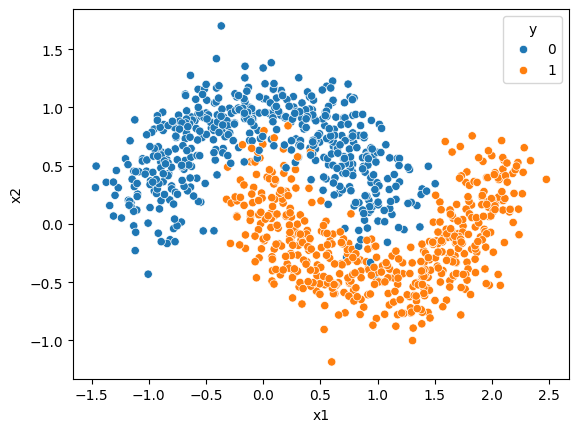

100.0 95.5
97.125 97.5
87.25 88.0
Voting Accuracy: 97.625 97.0
     dt  svm  gnb  vc
0     1    1    1   1
1     0    0    0   0
2     1    1    1   1
3     0    0    0   0
4     0    0    0   0
..   ..  ...  ...  ..
195   0    0    0   0
196   0    0    0   0
197   0    0    1   0
198   1    1    0   1
199   0    0    0   0

[200 rows x 4 columns]


In [3]:
x,y = make_moons(n_samples=1000,noise=0.2)
print(x,y)
df = {"x1":x[:,0],"x2":x[:,1],"y":y}
dataset = pd.DataFrame(df)
print(dataset.head())
sns.scatterplot(x="x1",y="x2",data=dataset,hue="y")
plt.show()
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]
x_train, x_test, y_train, y_test = train_test_split(x_a,y_a,test_size=0.2,random_state=13)
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
print(dt.score(x_train,y_train)*100,dt.score(x_test,y_test)*100)
sv = SVC()
sv.fit(x_train,y_train)
print(sv.score(x_train,y_train)*100,sv.score(x_test,y_test)*100)
gnb = GaussianNB()
gnb.fit(x_train,y_train)
print(gnb.score(x_train,y_train)*100,gnb.score(x_test,y_test)*100)
li = [
    ("dt1", DecisionTreeClassifier()),
    ("sv1", SVC(probability=True)),
    ("gnb1", GaussianNB())
]
vc = VotingClassifier(li,weights=[5,4,7])
vc.fit(x_train,y_train)
print("Voting Accuracy:",
      vc.score(x_train, y_train)*100,
      vc.score(x_test, y_test)*100)
prd = {"dt":dt.predict(x_test),"svm":sv.predict(x_test),"gnb":gnb.predict(x_test),"vc":vc.predict(x_test)}
print(pd.DataFrame(prd))

In [4]:
dataset = pd.read_csv("../datasets/cgpa_package.csv")
dataset.head()
dataset.isnull().sum()
x = dataset.iloc[:,:-1]
y = dataset["package"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(x_train,y_train)
print("LR:", lr.score(x_train,y_train)*100, lr.score(x_test,y_test)*100)
sv = SVR()
sv.fit(x_train,y_train)
print("SVR:", sv.score(x_train,y_train)*100, sv.score(x_test,y_test)*100)
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
print("DT:", dt.score(x_train,y_train)*100, dt.score(x_test,y_test)*100)
li = [
    ("lr1", LinearRegression()),
    ("sv1", SVR()),
    ("dt1", DecisionTreeRegressor())
]
vc = VotingRegressor(li,weights=[2, 4, 1])
vc.fit(x_train,y_train)
print("Voting Accuracy:",
      vc.score(x_train, y_train)*100,
      vc.score(x_test, y_test)*100)
df = {"lr":lr.predict(x_test),"dt":dt.predict(x_test),"svm":sv.predict(x_test),"vc":vc.predict(x_test)}
print(pd.DataFrame(df).head(5))

LR: 85.52251040585725 85.79606813451383
SVR: 87.20087854013273 88.2775917350433
DT: 95.27687993784821 83.11400374836576
Voting Accuracy: 89.28735840641349 88.05056695089554
         lr        dt       svm        vc
0  1.979230  1.980000  2.055578  2.022967
1  3.563685  3.490000  3.613838  3.581817
2  2.837477  2.873333  2.731989  2.782320
3  3.250095  3.240000  3.277404  3.264258
4  2.977767  2.730000  2.905945  2.901330


[[-0.72336886  0.33698399]
 [ 1.9031681  -0.01888824]
 [ 0.62151942 -0.35243137]
 ...
 [ 1.6140396  -0.31396634]
 [ 0.98281131  0.21151752]
 [ 0.88268998  0.30740447]] [0 1 1 1 1 1 0 1 0 1 1 0 0 1 0 1 1 1 0 1 1 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 1
 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0
 1 1 1 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0
 1 1 0 0 0 0 1 0 1 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0
 0 0 1 1 0 1 0 0 1 0 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1 0 0 1 1 1 1 0
 0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 1 0 1 1 0 1 1 1 1
 0 0 1 0 0 1 0 0 0 0 1 1 1 0 1 1 0 1 1 1 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1
 0 0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 1 0 1 0
 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1 0 0 1 0
 1 1 0 0 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0
 1 0 0 1 1 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1
 1 0 0 

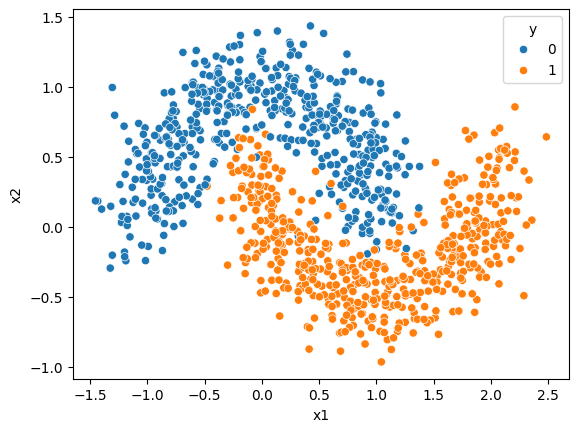

BG: 97.625 98.5
RF: 100.0 97.5


In [5]:
x,y = make_moons(n_samples=1000,noise=0.2)
print(x,y)
df = {"x1":x[:,0],"x2":x[:,1],"y":y}
dataset = pd.DataFrame(df)
print(dataset.head())
sns.scatterplot(x="x1",y="x2",data=dataset,hue="y")
plt.show()
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]
x_train, x_test, y_train, y_test = train_test_split(x_a,y_a,test_size=0.2,random_state=42)
bg = BaggingClassifier(estimator=SVC(),n_estimators=30)
bg.fit(x_train,y_train)
print("BG:", bg.score(x_train,y_train)*100, bg.score(x_test,y_test)*100)
rf = RandomForestClassifier(n_estimators=30)
rf.fit(x_train,y_train)
print("RF:", rf.score(x_train,y_train)*100, rf.score(x_test,y_test)*100)

In [ ]:
dataset = pd.read_csv("../datasets/cgpa_package.csv")
dataset.head()
dataset.isnull().sum()
x = dataset.iloc[:,:-1]
y = dataset["package"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
bg = BaggingRegressor(estimator=LinearRegression(),n_estimators=50, random_state=42)
bg.fit(x_train,y_train)
print("BG:", bg.score(x_train,y_train)*100, bg.score(x_test,y_test)*100)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(x_train,y_train)
print("RF:", rf.score(x_train,y_train)*100, rf.score(x_test,y_test)*100)


BG: 85.52154958770149 85.80514290466604
RF: 91.09181945513902 86.66621939190397


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [1]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()
model3 = SVC(probability=True)

ensemble = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('dt', model2),
        ('svm', model3)
    ],
    voting='soft'
)

ensemble.fit(x_train, y_train)

NameError: name 'x_train' is not defined

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification

# Dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Weak learner
base_model = DecisionTreeClassifier(max_depth=1)

# AdaBoost
ada = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.5
)

ada.fit(X_train, y_train)

print("Accuracy:", ada.score(X_test, y_test))


Accuracy: 0.872


In [9]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=1000, noise=20)

X_train, X_test, y_train, y_test = train_test_split(X, y)

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)

gbr.fit(X_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft